In [ ]:
# just a short notebook that runs some central dasm/dnsm data loading, to make sure that chothia to imgt transition went smoothly

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import glob

from netam.sequences import nt_mask_tensor_of, AA_STR_SORTED, CODONS, translate_codon
from netam.framework import encode_mut_pos_and_base

from shmex.shm_data import pcp_df_of_non_shmoof_nickname

from dnsmex import dnsm_oe, dasm_oe, dasm_zoo, dnsm_zoo
from dnsmex.local import localify

from utils import add_column_aa_one_mutation_away_from_aa

from dnsmex.neutral_mutability import MutabilityContainer
from netam.models import DEFAULT_NEUTRAL_MODEL




In [2]:
DATASET = 'v1rodriguez'
DATASET = 'v1rodriguez_short'
figures_dir = "/home/nharel/re/dasm-epistasis-experiments/_ignore/chothia_checks/"

In [3]:
# test out write_sites oe for dnsm


def test_dnsm_oe(dataset_name, numbering_scheme="imgt", remove_leaves=True):
    model_name = "dnsm_1m-v1jaffe+v1tang-joint"

    crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
    test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}-{numbering_scheme}")

    # Removed try-except to see what's happening in real-time
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dnsm_zoo.write_branch_lengths(
            localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}"), 
            dataset_name, 
            f"{test_output_prefix}.branch_lengths_csv"
        )

    complete_plotter, plotter_dict = dnsm_oe.write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4-{numbering_scheme}.svg",
        min_log_prob=-4,
        replace_title=True,
        numbering_scheme=numbering_scheme,  # NEW: Add numbering scheme parameter
    )
    complete_plotter = complete_plotter["heavy"]

    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    for column_name in ['selection_factor', 'neutral_prob', 'prob']:
        site_sub_probs_df[column_name] = site_sub_probs_df[column_name].apply(
            lambda x: x.item() if hasattr(x, 'item') else x
        )

    # add family annotations to aa and site substitution dfs
    pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
    pcp_df_for_merge = pcp_df.copy()
    pcp_df_for_merge = pcp_df_for_merge[[
        'v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family', 
        'distance', 'branch_length', 'parent_name', 'child_name', 'child_is_leaf'
    ]]
    pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

    site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')
    site_sub_probs_df['log_selection_factor'] = np.log(site_sub_probs_df['selection_factor'])
    
    return site_sub_probs_df, pcp_df



Loading /fh/fast/matsen_e/shared/bcr-mut-sel/working/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.short.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', '440')]
Loading model
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip
Loading branch lengths


Calculating model predictions: 100%|██████████| 1/1 [00:03<00:00,  3.88s/it]


Preparing heavy chain plot data


Calculating model predictions: 100%|██████████| 1/1 [00:03<00:00,  3.21s/it]


Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Loading /fh/fast/matsen_e/shared/bcr-mut-sel/working/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.short.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', '440')]
Loading model
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip
Loading branch lengths


Calculating model predictions: 100%|██████████| 1/1 [00:03<00:00,  3.60s/it]


Preparing heavy chain plot data


Calculating model predictions: 100%|██████████| 1/1 [00:03<00:00,  3.32s/it]


Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...


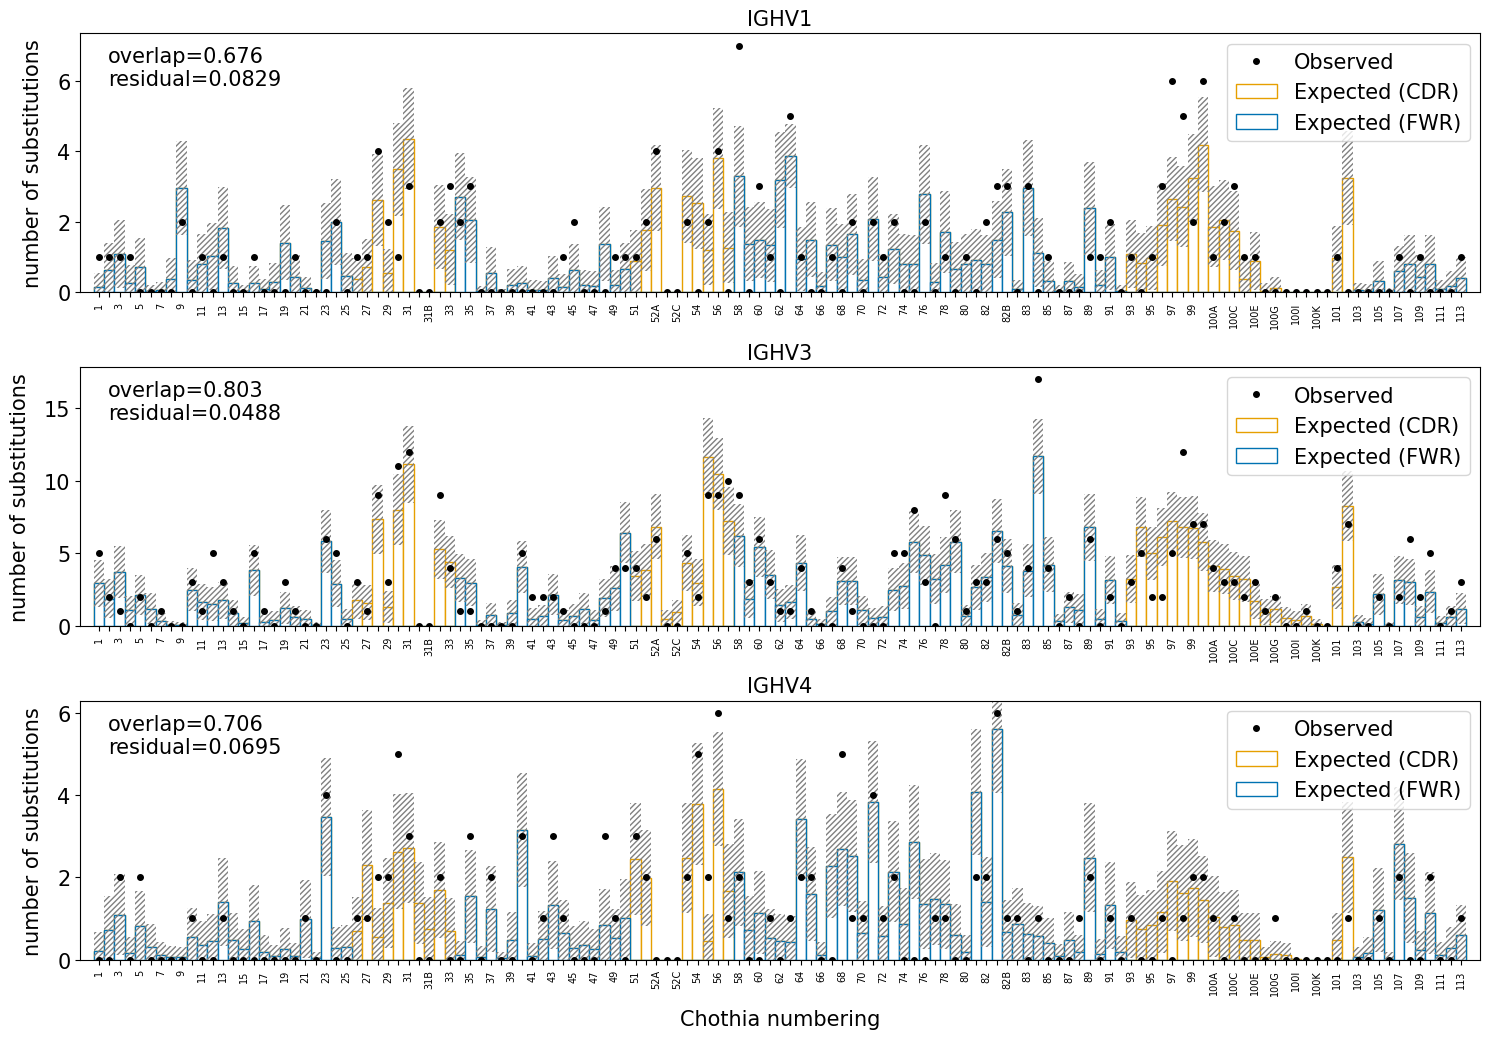

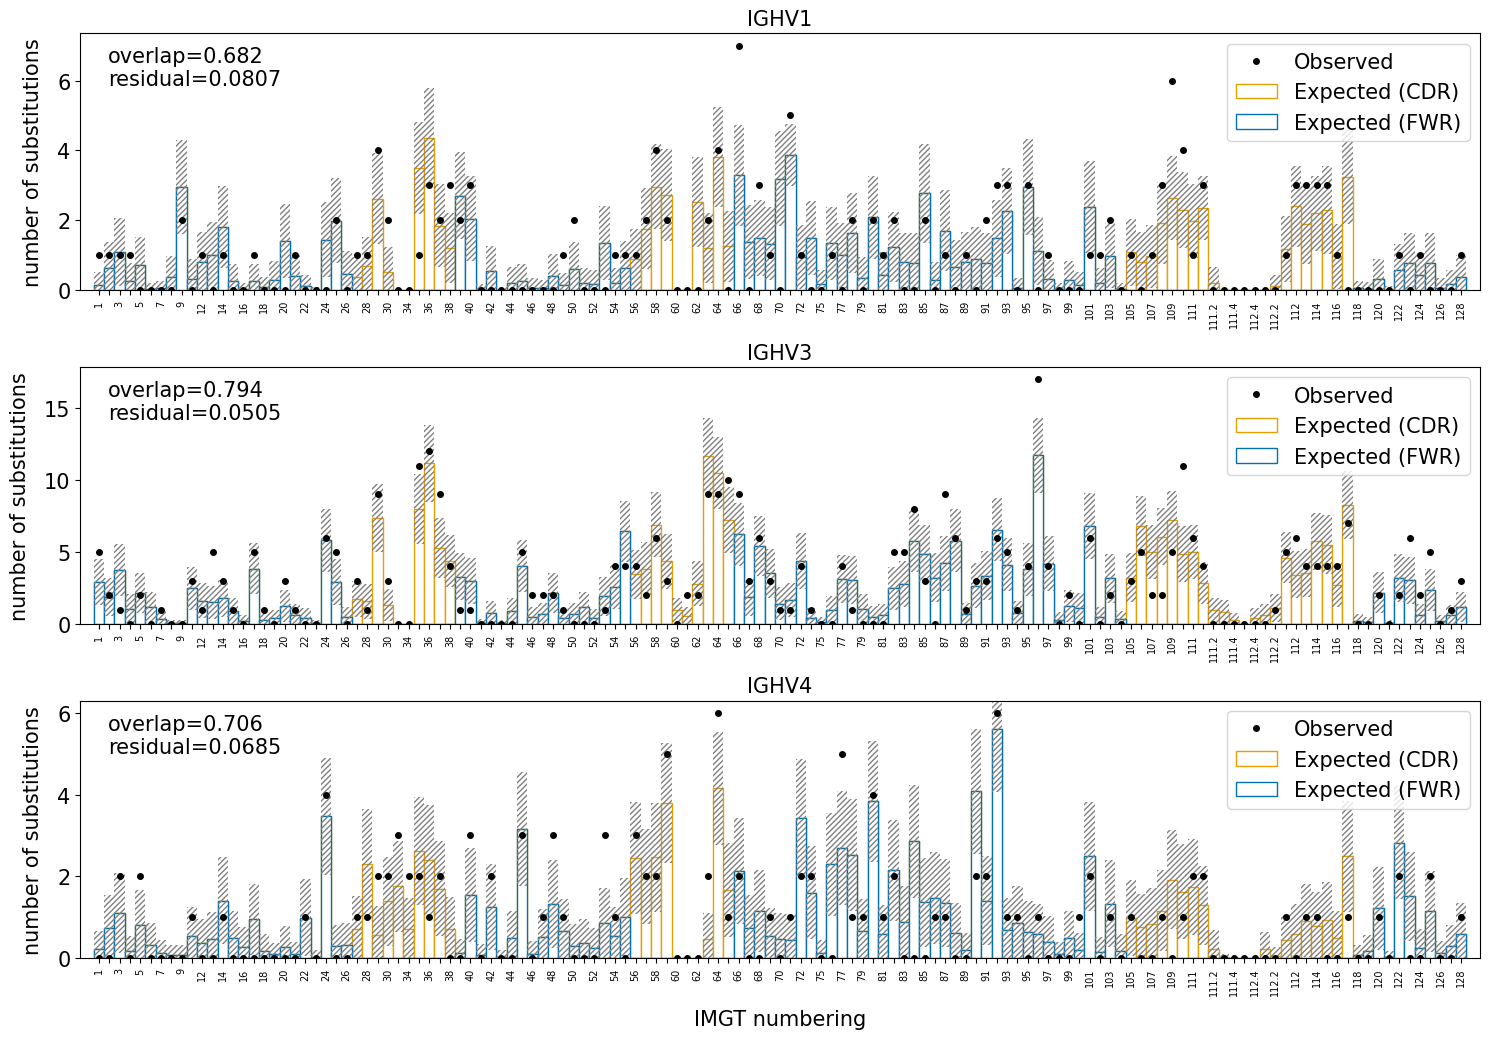

In [4]:
chothia_site_sub_probs_df, chothia_pcp_df = test_dnsm_oe(DATASET, numbering_scheme="chothia")
imgt_site_sub_probs_df, imgt_pcp_df = test_dnsm_oe(DATASET)

In [3]:
# test oe plot for DASM

def test_dasm_oe(dataset_name, numbering_scheme="imgt"):
    """Load or create DASM test output data.
    
    Args:
        dataset_name: Name of the dataset to test on
        model_name: Name of the trained DASM model
        numbering_scheme: Either "imgt" or "chothia". Default is "imgt".
        remove_leaves: Whether to remove leaf nodes (not currently used, for consistency)
    
    Returns:
        tuple: (site_sub_probs_df, pcp_df, aa_site_subs_selection_df)
    """
    model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"

    crepe_prefix = localify(f"DASM_TRAINED_MODELS_DIR/{model_name}")
    test_output_prefix = localify(f"DASM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}-{numbering_scheme}")

    # Removed try-except to see what's happening in real-time
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dasm_zoo.write_branch_lengths(
            localify(f"DASM_TRAINED_MODELS_DIR/{model_name}"), 
            dataset_name, 
            f"{test_output_prefix}.branch_lengths_csv"
        )

    complete_plotter, plotter_dict = dasm_oe.write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-{numbering_scheme}.svg",
        min_log_prob=-4,
        replace_title=True,
        numbering_scheme=numbering_scheme,  # NEW: Add numbering scheme parameter
    )
    complete_plotter = complete_plotter["heavy"]

    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    aa_site_subs_selection_df = complete_plotter.aa_site_subs_selection_df.copy()

    # add family annotations to aa and site substitution dfs
    pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
    pcp_df_for_merge = pcp_df.copy()
    pcp_df_for_merge = pcp_df_for_merge[[
        'v_gene', 'j_gene', 'v_family', 'j_family', 
        'sample_id', 'family', 'depth', 'distance'
    ]]
    pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

    site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')
    aa_site_subs_selection_df = pd.merge(aa_site_subs_selection_df, pcp_df_for_merge, on='pcp_index', how='inner')
    aa_site_subs_selection_df['log_selection_factor'] = np.log(aa_site_subs_selection_df.selection_factor)
    
    return site_sub_probs_df, pcp_df, aa_site_subs_selection_df

Loading /fh/fast/matsen_e/shared/bcr-mut-sel/working/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.short.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', '440')]
Loading model
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip


/home/nharel/re/netam/netam/dxsm.py:323: UserWarning: Model type is unknown. This is likely an old model that does not include its type (dnsm, ddsm, or dasm, etc.) in its metadata. Be sure the model type matches the Dataset and Burrito type.
  warn(


Loading branch lengths


Calculating model predictions: 100%|██████████| 1/1 [00:05<00:00,  5.35s/it]


Preparing heavy chain plot data
Invalid IMGT insertion: 68.1 sample-igg-SC-18 440
Invalid IMGT insertion: 119.1 sample-igg-W-37 140
Invalid IMGT insertion: 119.1 sample-igg-W-3 17
Invalid IMGT insertion: 119.1 sample-igg-W-34 200
Calculating oe csp dataframe


...

Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...


Calculating DASM selection factors: 100%|██████████| 1/1 [00:05<00:00,  5.26s/it]


Expanding 12037 rows into 240740 rows...


Expanding rows: 100%|██████████| 13/13 [00:02<00:00,  4.80it/s]


Creating expanded DataFrame...


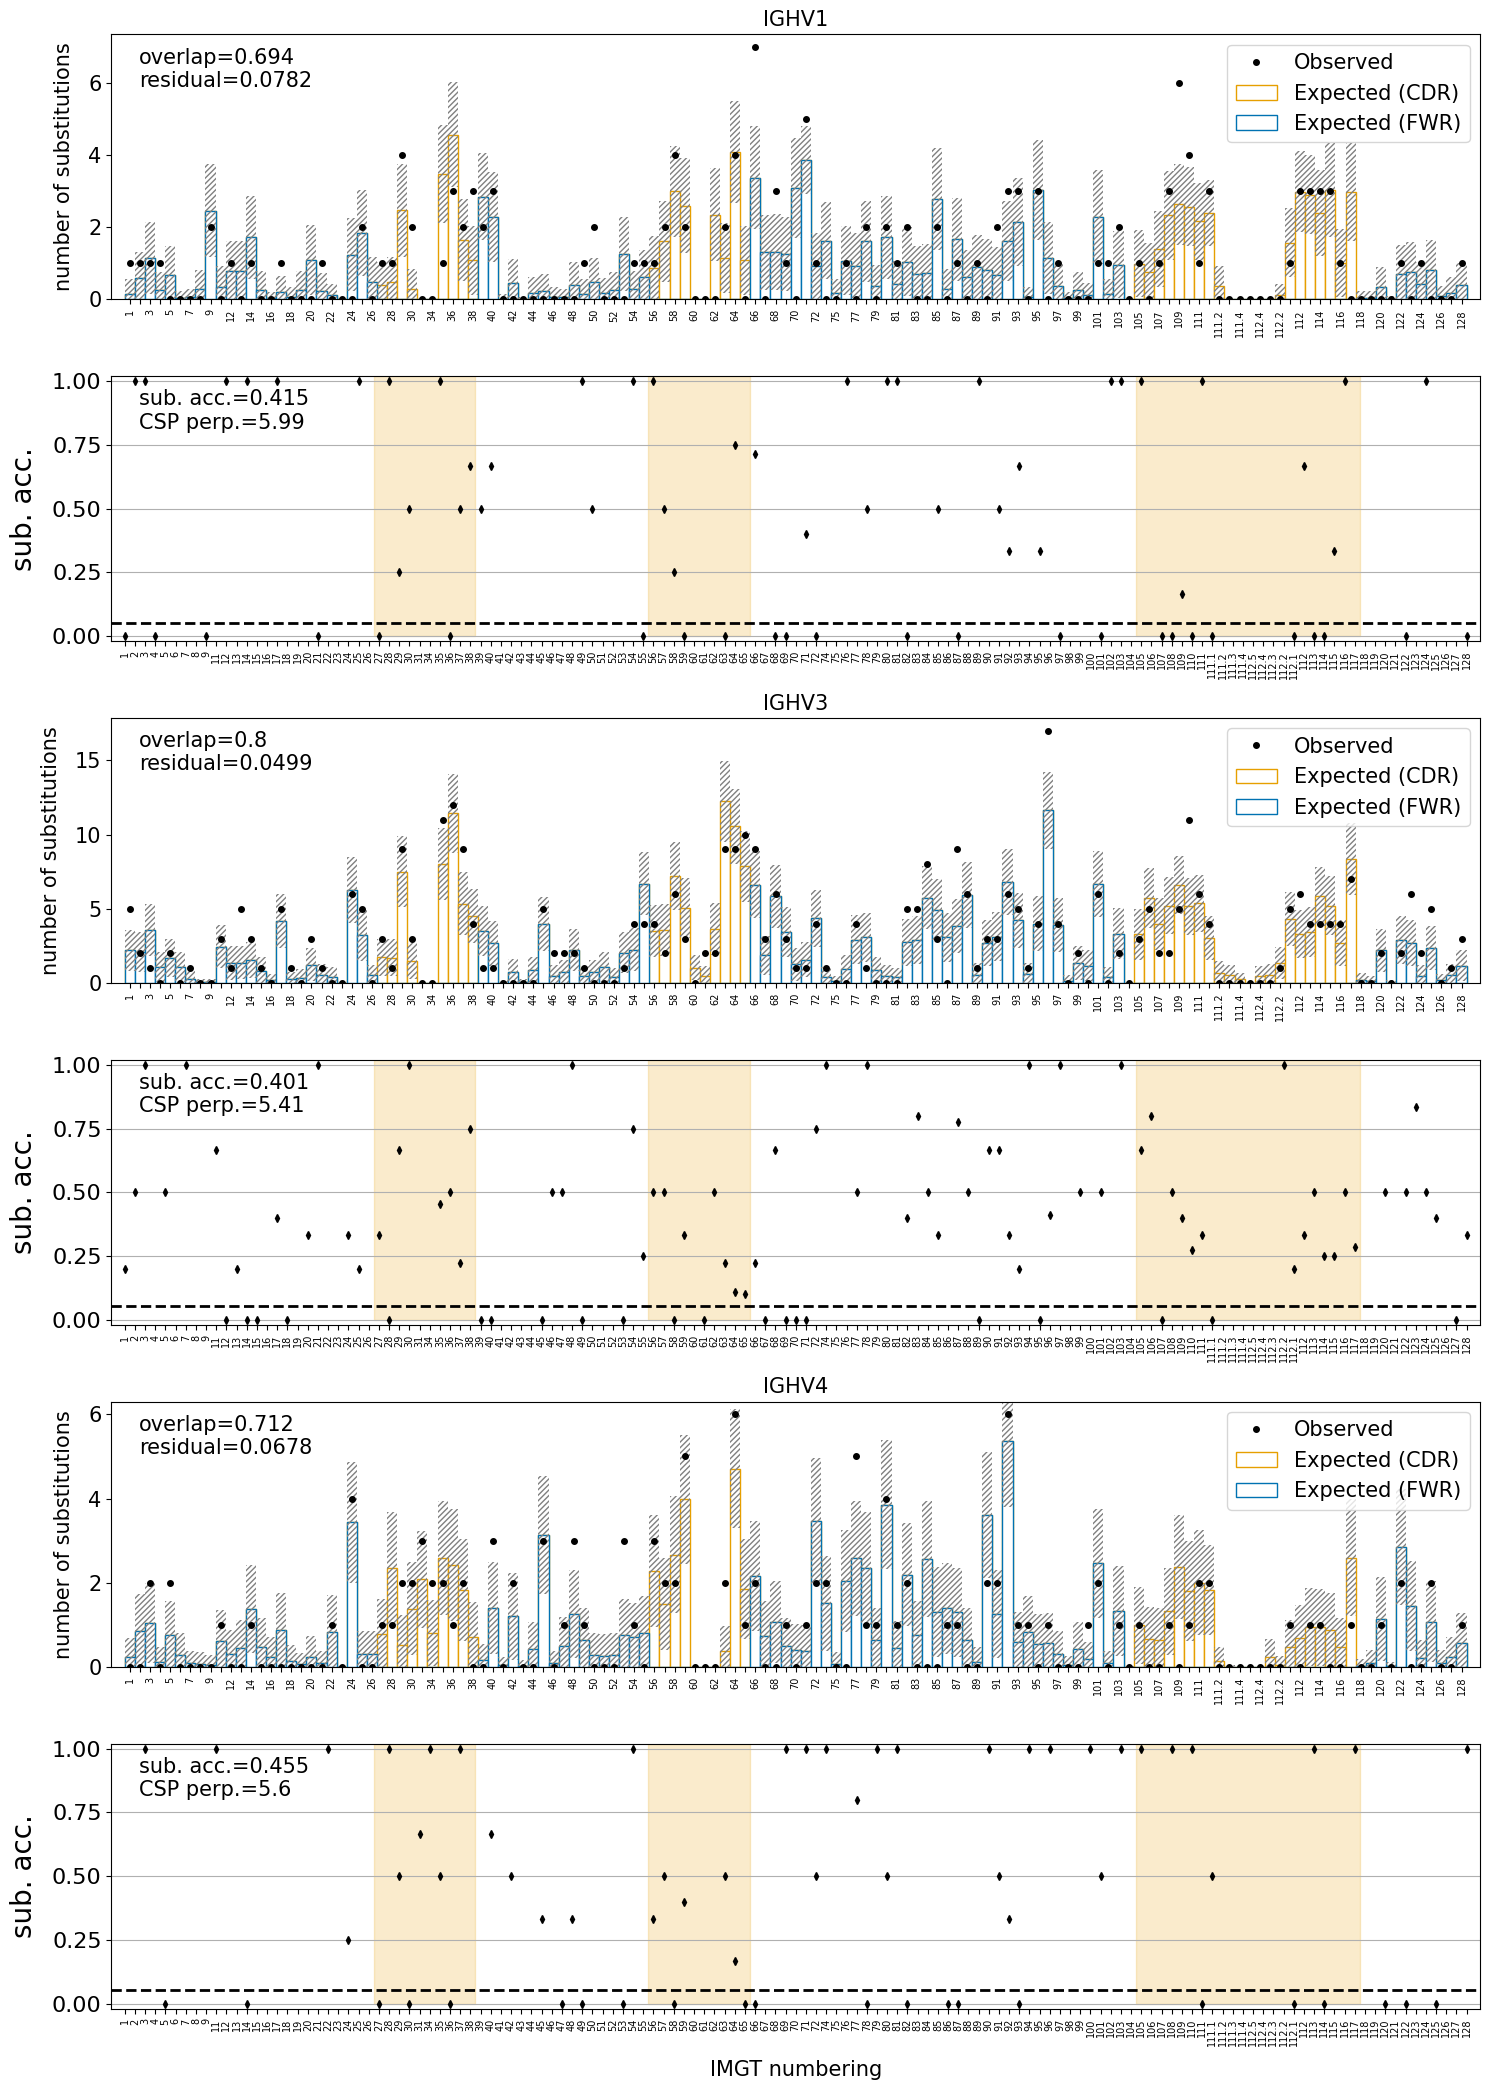

In [4]:
#chothia_site_sub_probs_df, chothia_pcp_df, chothia_aa_site_subs_selection_df = test_dasm_oe(DATASET, numbering_scheme="chothia")
imgt_site_sub_probs_df, imgt_pcp_df, imgt_aa_site_subs_selection_df = test_dasm_oe(DATASET)

Loading /fh/fast/matsen_e/shared/bcr-mut-sel/working/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.short.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', '440')]
Loading model
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip


/home/nharel/re/netam/netam/dxsm.py:323: UserWarning: Model type is unknown. This is likely an old model that does not include its type (dnsm, ddsm, or dasm, etc.) in its metadata. Be sure the model type matches the Dataset and Burrito type.
  warn(


Loading branch lengths


Calculating model predictions: 100%|██████████| 1/1 [00:05<00:00,  5.21s/it]


Preparing heavy chain plot data
Calculating oe csp dataframe


...

Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...


Calculating DASM selection factors: 100%|██████████| 1/1 [00:05<00:00,  5.92s/it]


Expanding 12037 rows into 240740 rows...


Expanding rows: 100%|██████████| 13/13 [00:02<00:00,  4.74it/s]


Creating expanded DataFrame...


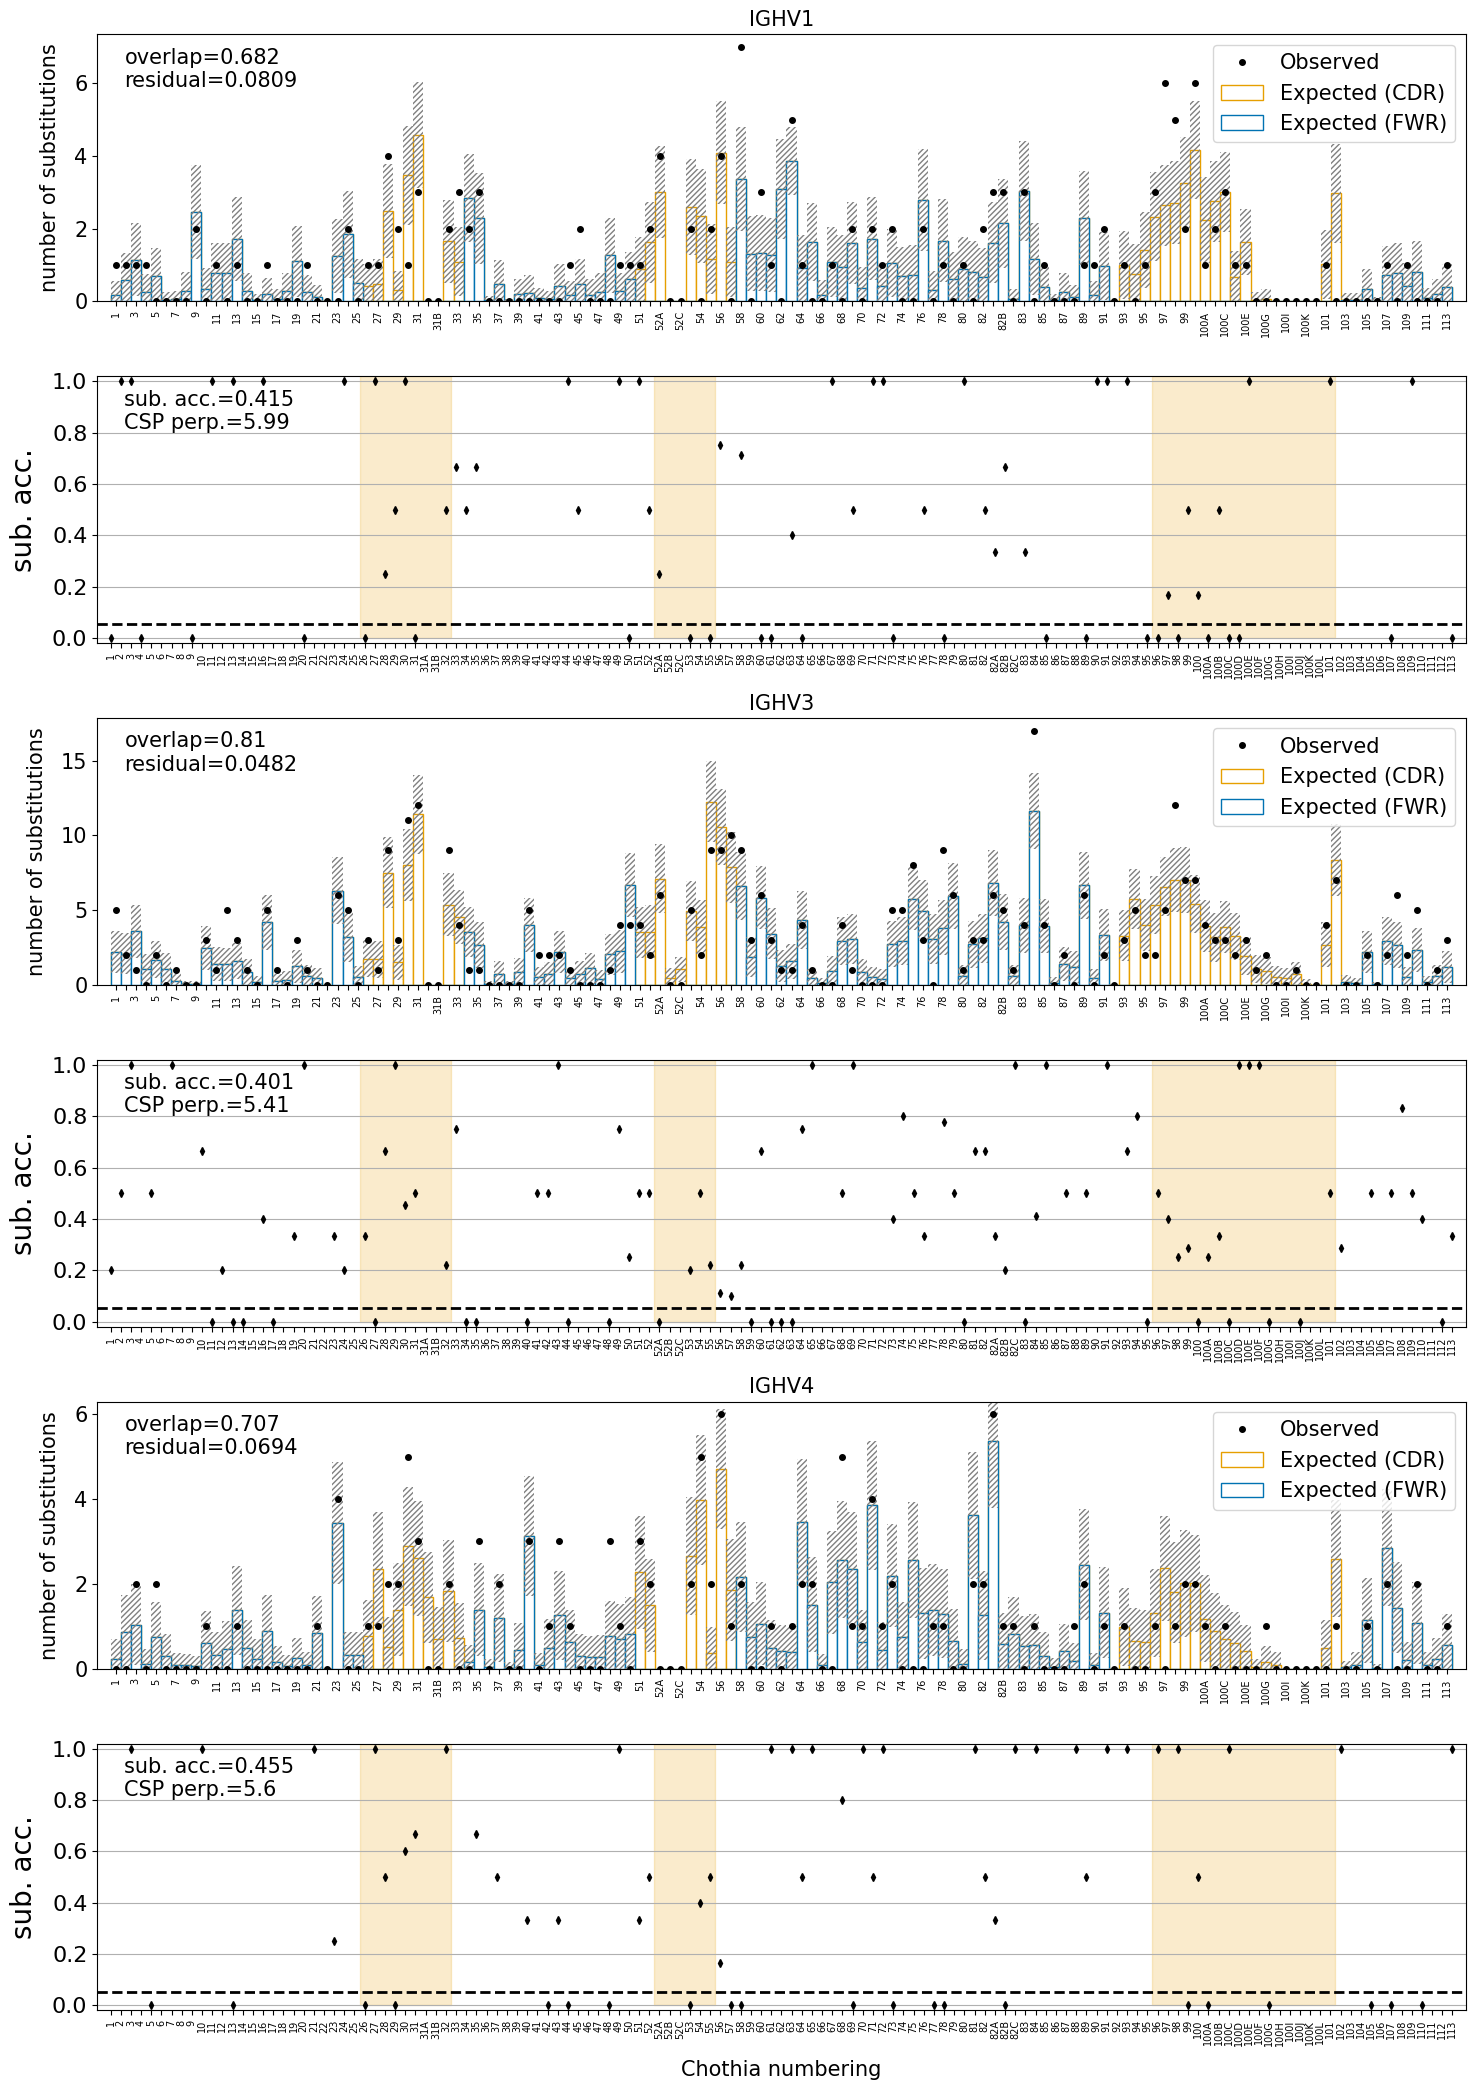

In [5]:
chothia_site_sub_probs_df, chothia_pcp_df, chothia_aa_site_subs_selection_df = test_dasm_oe(DATASET, numbering_scheme="chothia")


In [14]:
imgt_MutabilityContainer = MutabilityContainer(dataset="v1rodriguez_short", neutral_model_name=DEFAULT_NEUTRAL_MODEL)
chothia_MutabilityContainer = MutabilityContainer(dataset="v1rodriguez_short", neutral_model_name=DEFAULT_NEUTRAL_MODEL, numbering_scheme="chothia")



/home/nharel/re/dnsm-experiments-1/dnsmex/dxsm_data.py:534: UserWarning: Using ThriftyHumV0.2-59. Make sure this is an appropriate choice for your model, or use `netam.framework.add_shm_model_outputs_to_pcp_df` directly to provide the correct neutral model.
  warn(


Loading /fh/fast/matsen_e/shared/bcr-mut-sel/working/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.short.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', '440')]
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip
Using ANARCI path: {'heavy': '/home/nharel/data/v3/anarci/rodriguez-airr-seq-race-prod-NoWinCheck_igh_imgt.csv'}


Processing sequences to nucleotide-level rates: 100%|██████████| 99/99 [00:00<00:00, 117.18it/s]
/home/nharel/re/dnsm-experiments-1/dnsmex/dxsm_data.py:534: UserWarning: Using ThriftyHumV0.2-59. Make sure this is an appropriate choice for your model, or use `netam.framework.add_shm_model_outputs_to_pcp_df` directly to provide the correct neutral model.
  warn(


Loading /fh/fast/matsen_e/shared/bcr-mut-sel/working/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.short.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', '440')]
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip
Using ANARCI path: {'heavy': '/fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v3/anarci/rodriguez-airr-seq-race-prod-NoWinCheck_igh_anarci-seqs_chothia_H.csv'}


Processing sequences to nucleotide-level rates: 100%|██████████| 99/99 [00:00<00:00, 115.43it/s]


In [15]:
imgt_MutabilityContainer.aa_neutral_df

,pcp_index,site,current_aa,transition_aa,parent_codon,parent_aa,child_codon,child_aa,is_cdr,substitution_probability
0,0,1,(Q),(K),CAG,Q,CAG,Q,False,0.007175
1,0,1,(Q),(Q),CAG,Q,CAG,Q,False,0.034324
2,0,1,(Q),(E),CAG,Q,CAG,Q,False,0.009303
3,0,1,(Q),(*),CAG,Q,CAG,Q,False,0.014215
4,0,1,(Q),(P),CAG,Q,CAG,Q,False,0.011440
...,...,...,...,...,...,...,...,...,...,...
85246,98,128,(S),(P),TCA,S,TCA,S,False,0.013223
85247,98,128,(S),(A),TCA,S,TCA,S,False,0.005529
85248,98,128,(S),(S),TCA,S,TCA,S,False,0.043716
85249,98,128,(S),(*),TCA,S,TCA,S,False,0.014172


In [16]:
chothia_MutabilityContainer.aa_neutral_df

,pcp_index,site,current_aa,transition_aa,parent_codon,parent_aa,child_codon,child_aa,is_cdr,substitution_probability
0,0,1,(Q),(K),CAG,Q,CAG,Q,False,0.007175
1,0,1,(Q),(Q),CAG,Q,CAG,Q,False,0.034324
2,0,1,(Q),(E),CAG,Q,CAG,Q,False,0.009303
3,0,1,(Q),(*),CAG,Q,CAG,Q,False,0.014215
4,0,1,(Q),(P),CAG,Q,CAG,Q,False,0.011440
...,...,...,...,...,...,...,...,...,...,...
85246,98,113,(S),(P),TCA,S,TCA,S,False,0.013223
85247,98,113,(S),(A),TCA,S,TCA,S,False,0.005529
85248,98,113,(S),(S),TCA,S,TCA,S,False,0.043716
85249,98,113,(S),(*),TCA,S,TCA,S,False,0.014172
